<b><font color="#1f4e79" size="7">
Notebook 1:
<br></font></b>

<b><font color="#1f4e79" size="6">
Downloading rs-fMRI Data and ROI Time-Series Extraction
</font></b>

<hr>



This notebook implements a complete pipeline for:

- Downloading preprocessed resting-state fMRI data from OpenNeuro (ds002748)
- Validating data integrity across subjects
- Extracting ROI-level time series using the AAL3 atlas
- Applying confound regression, temporal filtering, and standardization
- Saving extracted signals for downstream analysis


# Setup

## Install & Imports

In [2]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

!pip install -q awscli nilearn
from nilearn import plotting, datasets, image
from nilearn.maskers import NiftiLabelsMasker


## Downloading the ds002748 Dataset

In this section, we download the **preprocessed resting-state BOLD fMRI** and corresponding **confound files** for all 72 participants in the ds002748 dataset.

The dataset includes:
- 21 healthy controls (HC)
- 51 patients with major depressive disorder (MDD)

The download takes about 5 minutes on Google Colab.

In [3]:
!aws s3 sync s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/ /content/ds002748/ \
    --no-sign-request \
    --exclude "*" \
    --include "*_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz" \
    --include "*_desc-confounds_timeseries.tsv"

download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-02/func/sub-02_task-rest_desc-confounds_timeseries.tsv to ds002748/sub-02/func/sub-02_task-rest_desc-confounds_timeseries.tsv
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-01/func/sub-01_task-rest_desc-confounds_timeseries.tsv to ds002748/sub-01/func/sub-01_task-rest_desc-confounds_timeseries.tsv
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-03/func/sub-03_task-rest_desc-confounds_timeseries.tsv to ds002748/sub-03/func/sub-03_task-rest_desc-confounds_timeseries.tsv
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-01/func/sub-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz to ds002748/sub-01/func/sub-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
download: s3://openneuro-derivatives/fmriprep/ds002748-fmriprep/sub-02/func/sub-02_task-rest_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz to ds002748/sub-02/f

## Data Integrity Validation

Before proceeding to time-series extraction, we verify that:

- Each subject has both required files:
  - Preprocessed BOLD fMRI
  - Confound regressors
- Imaging parameters are consistent across subjects:
  - Spatial dimensions (image shape)
  - Number of timepoints (volumes)
  - Repetition time (TR)

In [4]:
summary = []

base_dir = Path("/content/ds002748")

for subject_dir in sorted(base_dir.glob("sub-*")):
    subject = subject_dir.name
    func_dir = subject_dir / "func"

    nii_files = list(func_dir.glob("*_desc-preproc_bold.nii.gz"))
    tsv_files = list(func_dir.glob("*_desc-confounds_timeseries.tsv"))

    if (len(nii_files) != 1 or len(tsv_files) != 1):
        print(
            f"{subject}: "
            f"BOLD={len(nii_files)}, "
            f"Confounds={len(tsv_files)}, "
        )
        continue

    img = image.load_img(nii_files[0])

    summary.append({
        "subject": subject,
        "shape": img.shape[:3],
        "n_volumes": img.shape[-1],
        "TR": round(img.header.get_zooms()[-1], 3),
    })

df = pd.DataFrame(summary)
print(df.head())

print(f"\nSubjects found: {len(df)}")
print(f"Unique TRs: {df['TR'].unique()}")
print(f"Unique volumes: {df['n_volumes'].unique()}")

  subject          shape  n_volumes   TR
0  sub-01  (97, 115, 97)        100  2.5
1  sub-02  (97, 115, 97)        100  2.5
2  sub-03  (97, 115, 97)        100  2.5
3  sub-04  (97, 115, 97)        100  2.5
4  sub-05  (97, 115, 97)        100  2.5

Subjects found: 72
Unique TRs: [2.5]
Unique volumes: [100]


## Load AAL3 Atlas (ROI Parcellation)

The AAL3 (Automated Anatomical Labeling 3) atlas provides 166 cortical and subcortical regions in MNI space.

In [5]:
!wget --no-check-certificate "https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz" --quiet
!tar -xzf /content/AAL3v2_for_SPM12.tar.gz

atlas = image.load_img("/content/AAL3/AAL3v1.nii.gz")

labels_path = "/content/AAL3/AAL3v1.nii.txt"

# ROI Time-Series Extraction

## Define Dataset Paths

In [6]:
base_dir = Path("/content/ds002748")

output_dir = Path("/content/timeseries")
output_dir.mkdir(exist_ok=True)

## Atlas Resampling

The AAL3 atlas is resampled to the functional MRI space of the dataset using nearest-neighbor interpolation.

In [7]:
first_subject = sorted(base_dir.glob("sub-*"))[0]
first_func = list((first_subject / "func").glob("*_desc-preproc_bold.nii.gz"))[0]

atlas_resampled = image.resample_to_img(
    atlas,
    first_func,
    interpolation="nearest"
)

print("Atlas resampled to functional space.")

Atlas resampled to functional space.


## Create ROI Mapping

The resampled atlas is inspected to identify active ROI labels.

A mapping between atlas ROI numbers and columns of the extracted time-series matrix is created. This ensures that each signal can be traced back to its anatomical region.

In [8]:
atlas_data = atlas_resampled.get_fdata()
unique_labels = np.unique(atlas_data)
unique_labels = unique_labels[unique_labels != 0]
sorted_labels = sorted(unique_labels.astype(int))

roi_to_column = {roi: idx for idx, roi in enumerate(sorted_labels)}

print(f"Active ROIs in atlas: {len(sorted_labels)}")

Active ROIs in atlas: 166


## ROI Time-Series Extraction Function

The function below extracts ROI-level BOLD time series from a preprocessed resting-state fMRI scan.

The extraction pipeline includes:

- Confound regression using motion and physiological regressors.
- Linear detrending.
- Z-score standardization.
- Temporal band-pass filtering (0.01–0.1 Hz).

**Input**

- `fmri_file`: Preprocessed resting-state fMRI image.
- `confounds_file`: Confound regressors generated by fMRIPrep.
- `atlas_resampled`: Atlas aligned to the functional image.

**Output**

- ROI time-series matrix with shape **(Timepoints × ROIs)**.

In [9]:
def extract_roi_timeseries(
    fmri_file,
    confounds_file,
    atlas_resampled
):

    confounds_df = pd.read_csv(confounds_file, sep="\t")

    confounds = confounds_df[[
        'trans_x', 'trans_y', 'trans_z',
        'rot_x', 'rot_y', 'rot_z',
        'csf', 'white_matter'
    ]].fillna(0)


    masker = NiftiLabelsMasker(
        labels_img=atlas_resampled,
        standardize="zscore_sample",
        detrend=True,
        t_r=2.5,
        low_pass=0.1,
        high_pass=0.01
    )

    time_series = masker.fit_transform(fmri_file, confounds=confounds)

    return time_series

## Batch ROI Extraction

The extraction function is applied to every participant in the dataset.

Each participant produces one ROI time-series matrix with dimensions:

$$
\text{Timepoints} \times \text{ROIs}
$$

The extracted matrices are saved individually as NumPy files for downstream analyses.

In [10]:
for subject_dir in sorted(base_dir.glob("sub-*")):

    subject = subject_dir.name

    func_dir = subject_dir / "func"

    nii_files = list(func_dir.glob("*_desc-preproc_bold.nii.gz"))

    tsv_files = list(func_dir.glob("*_desc-confounds_timeseries.tsv"))

    if len(nii_files) != 1 or len(tsv_files) != 1:
        print(f"{subject} skipped.")
        continue

    time_series = extract_roi_timeseries(
        nii_files[0],
        tsv_files[0],
        atlas_resampled
    )


    save_path = output_dir / f"{subject}_timeseries.npy"

    np.save(save_path, time_series)

    print(f"{subject} processed. Shape: {time_series.shape}")

sub-01 processed. Shape: (100, 166)
sub-02 processed. Shape: (100, 166)
sub-03 processed. Shape: (100, 166)
sub-04 processed. Shape: (100, 166)
sub-05 processed. Shape: (100, 166)
sub-06 processed. Shape: (100, 166)
sub-07 processed. Shape: (100, 166)
sub-08 processed. Shape: (100, 166)
sub-09 processed. Shape: (100, 166)
sub-10 processed. Shape: (100, 166)
sub-11 processed. Shape: (100, 166)
sub-12 processed. Shape: (100, 166)
sub-13 processed. Shape: (100, 166)
sub-14 processed. Shape: (100, 166)
sub-15 processed. Shape: (100, 166)
sub-16 processed. Shape: (100, 166)
sub-17 processed. Shape: (100, 166)
sub-18 processed. Shape: (100, 166)
sub-19 processed. Shape: (100, 166)
sub-20 processed. Shape: (100, 166)
sub-21 processed. Shape: (100, 166)
sub-22 processed. Shape: (100, 166)
sub-23 processed. Shape: (100, 166)
sub-24 processed. Shape: (100, 166)
sub-25 processed. Shape: (100, 166)
sub-26 processed. Shape: (100, 166)
sub-27 processed. Shape: (100, 166)
sub-28 processed. Shape: (10

## Generate ROI Metadata

To preserve the correspondence between matrix columns and anatomical regions, a metadata file is generated after all ROI time series have been extracted.

The metadata includes:

- Atlas information.
- Number of active ROIs.
- Mapping between ROI labels and matrix columns.
- Mapping between matrix columns and ROI names.
- Deprecated AAL3 regions that are absent from the atlas image.

The resulting `extraction_metadata.json` is reused in the subsequent notebooks to correctly interpret ROI-based features and connectivity matrices.

In [11]:
metadata_path = Path("/content/extraction_metadata.json")

atlas_data = image.load_img(atlas_resampled).get_fdata()
unique_labels = np.unique(atlas_data)
unique_labels = unique_labels[unique_labels != 0]
sorted_labels = sorted(unique_labels.astype(int))

roi_to_column = {roi: idx for idx, roi in enumerate(sorted_labels)}

roi_names = {}
with open(labels_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            roi_num = int(parts[0])
            roi_name = parts[1]
            roi_names[roi_num] = roi_name

for roi in [35, 36, 81, 82]:
    print(f"ROI {roi}: '{roi_names[roi]}' — present in image? {roi in roi_to_column}")

column_names = [roi_names[roi_num] for roi_num in sorted_labels]

print(f"\nNumber of columns: {len(column_names)}")

metadata = {
    "atlas": "AAL3v1",
    "n_timepoints": 100,
    "n_rois_in_image": len(sorted_labels),
    "deprecated_rois": [35, 36, 81, 82],
    "column_to_roi": {str(i): int(roi) for i, roi in enumerate(sorted_labels)},
    "column_to_name": {str(i): column_names[i] for i in range(len(column_names))},
    "roi_to_column": {str(roi): idx for roi, idx in roi_to_column.items()},
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved to extraction_metadata.json")

ROI 35: 'Cingulate_Ant_L' — present in image? False
ROI 36: 'Cingulate_Ant_R' — present in image? False
ROI 81: 'Thalamus_L' — present in image? False
ROI 82: 'Thalamus_R' — present in image? False

Number of columns: 166
Metadata saved to extraction_metadata.json


## Visualize Extracted ROI Signals

The function below visualizes the extracted BOLD signal of any ROI from any participant.

Given a subject ID and an AAL3 ROI number, it:

- Locates the corresponding ROI in the atlas.
- Retrieves the extracted BOLD time series.
- Displays the highlighted ROI together with its standardized signal.

In [12]:
def plot_roi_timeseries(
    subject_id,
    roi_index
):

    time_series = np.load(f"/content/timeseries/{subject_id}_timeseries.npy")

    with open("/content/extraction_metadata.json", "r") as f:
        metadata = json.load(f)

    column_to_roi = {
        int(k): v
        for k, v in metadata["column_to_roi"].items()
    }

    column_to_name = {
        int(k): v
        for k, v in metadata["column_to_name"].items()
    }

    if roi_index not in column_to_roi:
        print("ROI index not found.")
        return

    roi_label = column_to_roi[roi_index]

    signal = time_series[:, roi_index]

    roi_name = column_to_name[roi_index]

    roi_mask = image.math_img(
        f"img == {roi_label}",
        img=atlas_resampled
    )

    fig = plt.figure(figsize=(14, 5))

    fig.suptitle(
        f"Subject {subject_id.replace('sub-', '')} — {roi_name}",
        fontsize=15,
        x=0.05,
        ha="left",
        y=0.85
    )

    ax1 = fig.add_axes([0.02, 0.15, 0.35, 0.70])

    plotting.plot_roi(
        roi_mask,
        axes=ax1,
        display_mode="ortho",
        draw_cross=False,
        colorbar=False,
        cmap="autumn"
    )


    ax2 = fig.add_axes([0.43, 0.25, 0.52, 0.45])

    ax2.plot(
        signal,
        color="crimson",
        linewidth=2.5
    )

    ax2.set_title("BOLD Time Series", fontsize=15)

    ax2.set_xlabel("Timepoints")

    ax2.set_ylabel("Z-scored Signal")

    ax2.grid(True, alpha=0.3)

    plt.show()

### Example Visualizations

Example BOLD signals extracted from selected ROIs of **Subject 01**.

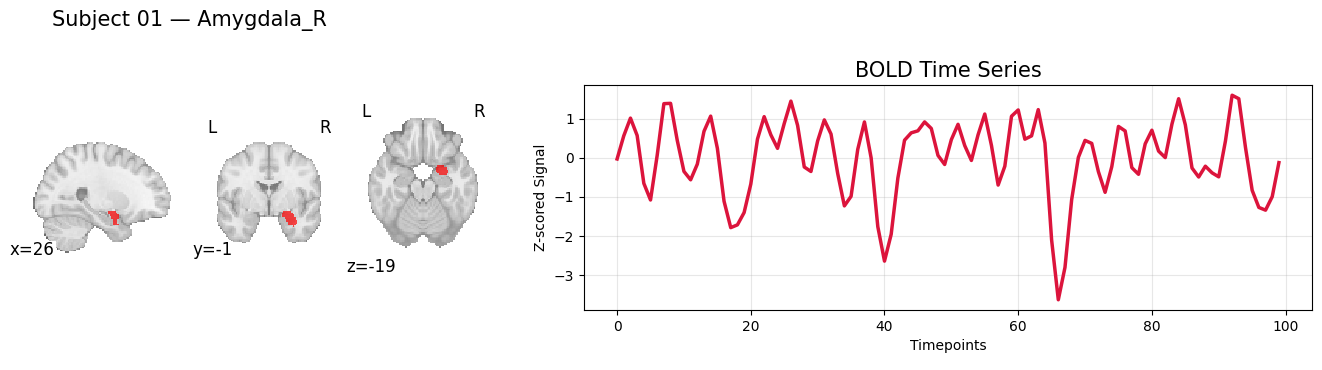

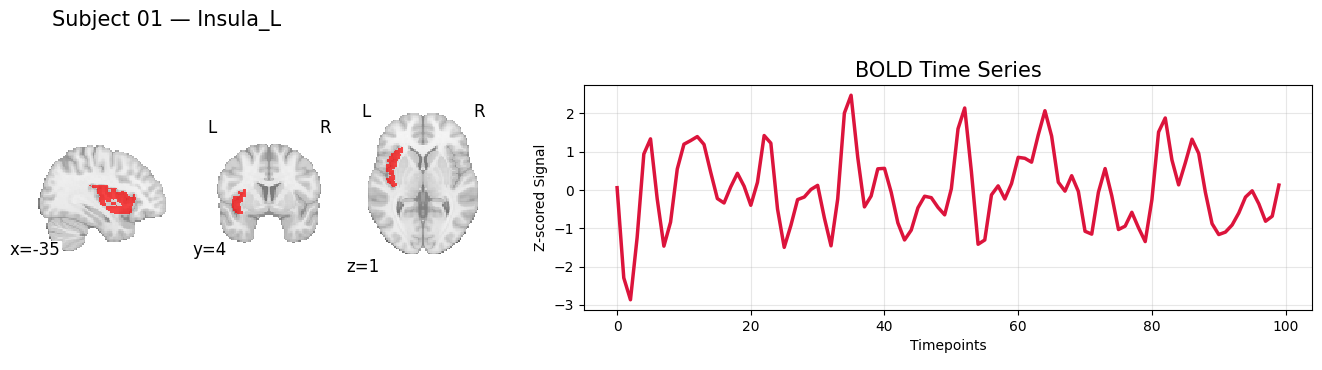

In [13]:
plot_roi_timeseries(
    subject_id="sub-01",
    roi_index=43
)

plot_roi_timeseries(
    subject_id="sub-01",
    roi_index=32
)

## Save Outputs


In [14]:
output_dir = Path("/content/timeseries")
zip_path = "/content/AAL3_timeseries_all_subjects.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in output_dir.glob("*.npy"):
        zipf.write(file, arcname=file.name)

    zipf.write(
        "/content/extraction_metadata.json",
        arcname="extraction_metadata.json"
    )

print("\nAll time-series extracted and compressed successfully.")
print(f"Zip file saved at: {zip_path}")


All time-series extracted and compressed successfully.
Zip file saved at: /content/AAL3_timeseries_all_subjects.zip
